# 11.1 — Stochastic baseline uncertainty

**Question.** How much do historical selected-policy outcomes vary across optimizer seeds at fixed defaults? The `test` profile is a seconds-to-minutes smoke run on deterministic synthetic cells; `screen` and `full` are substantial historical-optimizer runs on the env-resolved feature table. The exact optimizer count is printed before execution.

Runs resume from signed artifacts below `SENSITIVITY_OUTPUT_ROOT` (default `data/processed/legacy_sensitivity`); set `SENSITIVITY_OVERWRITE=true` only to recompute them. Intervals describe optimizer-seed uncertainty, not empirical uncertainty in Estonian land use, and comparisons remain conditional on the preserved Notebook 10 model and selection rules.

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from estonia_landuse.sensitivity.analysis import summarize_baseline
from estonia_landuse.sensitivity.config import DEFAULT_SEEDS
from estonia_landuse.sensitivity.historical_model import SCENARIO_LABELS
from estonia_landuse.sensitivity.plots import plot_baseline_uncertainty
from estonia_landuse.sensitivity.runner import run_manifest
from estonia_landuse.sensitivity.sampling import (
    build_baseline_manifest,
    manifest_run_count,
    manifest_summary,
)

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
HISTORICAL_ROOT = (
    PROJECT_ROOT.parent.parent
    if PROJECT_ROOT.parent.name == ".worktrees"
    else PROJECT_ROOT
)
# PROFILE = os.environ.get("SENSITIVITY_PROFILE", "test")
PROFILE = os.environ.get("SENSITIVITY_PROFILE", "full")
N_WORKERS = int(os.environ.get("SENSITIVITY_N_WORKERS", "4"))
OVERWRITE = os.environ.get("SENSITIVITY_OVERWRITE", "false").lower() == "true"
OUTPUT_ROOT = Path(os.environ.get("SENSITIVITY_OUTPUT_ROOT", PROJECT_ROOT / "data/processed/legacy_sensitivity")).resolve()
FEATURES_PATH = Path(os.environ.get("SENSITIVITY_FEATURES_PATH", HISTORICAL_ROOT / "data/processed/learned_carbon/features_with_forest.parquet")).resolve()
SEEDS = (0, 1) if PROFILE == "test" else DEFAULT_SEEDS[PROFILE]
SCENARIOS = ("balanced",) if PROFILE == "test" else tuple(SCENARIO_LABELS)
OUTCOMES = ("biodiversity_gain", "carbon_gain", "cost", "changed_pct")


In [2]:
if PROFILE == "test":
    position = np.linspace(0.0, 1.0, 12)
    context = pd.DataFrame({
        "cell_id": np.arange(1, 13), "forest_pct": 0.35 + 0.03 * position,
        "wetland_pct": 0.10 + 0.02 * position, "agriculture_pct": 0.30 - 0.03 * position,
        "grassland_pct": 0.15 - 0.02 * position, "urban_pct": np.full(12, 0.05),
        "water_pct": np.full(12, 0.05), "protected_overlap_pct": 0.05 * position,
        "wetland_suitability": 0.2 + 0.6 * position, "opportunity_cost_proxy": 0.1 + 0.5 * position,
        "predicted_tco2_ha_yr": 2.5 + 2.0 * position, "peat_overlap_pct": 0.4 * position,
    })
    feature_columns = ["wetland_suitability", "opportunity_cost_proxy"]
else:
    if not FEATURES_PATH.exists():
        raise FileNotFoundError(f"Missing historical feature input: {FEATURES_PATH}")
    context = pd.read_parquet(FEATURES_PATH)
    feature_columns = [name for name in ("urban_pct", "agriculture_pct", "grassland_pct", "forest_pct", "wetland_pct", "water_pct", "naturalness_score", "carbon_score", "protected_overlap_pct", "wetland_suitability", "biodiversity_proxy", "opportunity_cost_proxy", "rohemeeter_norm") if name in context]
    if not feature_columns:
        raise ValueError("No preserved Notebook 10 feature columns found")


In [3]:
manifest = build_baseline_manifest(profile=PROFILE, scenarios=SCENARIOS, seeds=SEEDS)
planned_runs = manifest_run_count(manifest)
manifest_summary(manifest)
display(manifest.head(6))


baseline: 18 optimizer runs (profile=full)


,experiment,sample_id,scenario,seed,profile,overrides,status
0,baseline,baseline,green_maximum,42,full,{},pending
1,baseline,baseline,green_maximum,73,full,{},pending
2,baseline,baseline,green_maximum,101,full,{},pending
3,baseline,baseline,food_security,42,full,{},pending
4,baseline,baseline,food_security,73,full,{},pending
5,baseline,baseline,food_security,101,full,{},pending


In [4]:
statuses = run_manifest(
    context, feature_columns, manifest, OUTPUT_ROOT, PROFILE, overwrite=OVERWRITE,
    n_workers=min(N_WORKERS, planned_runs),
    progress=lambda completed, total, status: print(f"[{completed}/{total}] {status}"),
)
if statuses["status"].eq("failed").any():
    raise RuntimeError(statuses.loc[statuses["status"].eq("failed"), ["scenario", "seed", "error_message"]].to_string(index=False))
assert len(statuses) == planned_runs
display(statuses["status"].value_counts())


[1/18] completed
[2/18] completed
[3/18] completed
[4/18] completed
[5/18] completed
[6/18] completed
[7/18] completed
[8/18] completed
[9/18] completed
[10/18] completed
[11/18] completed
[12/18] completed
[13/18] completed
[14/18] completed
[15/18] completed
[16/18] completed
[17/18] completed
[18/18] completed


status
completed    18
Name: count, dtype: int64

,scenario,outcome,mean,sd,n_seeds,ci95_low,ci95_high
0,balanced,biodiversity_gain,0.012649,0.000783,3,0.010704,0.014594
1,balanced,carbon_gain,0.023233,0.003084,3,0.015572,0.030893
2,balanced,changed_pct,0.067962,0.007521,3,0.049278,0.086645
3,balanced,cost,0.131905,0.013346,3,0.098753,0.165057
4,food_security,biodiversity_gain,0.009265,0.000079,3,0.009069,0.009462
5,food_security,carbon_gain,0.031745,0.000181,3,0.031295,0.032195
6,food_security,changed_pct,0.097433,0.001669,3,0.093287,0.101579
7,food_security,cost,0.370008,0.028764,3,0.298553,0.441463
8,green_maximum,biodiversity_gain,0.044432,0.000136,3,0.044095,0.044769
9,green_maximum,carbon_gain,0.063318,0.000253,3,0.062689,0.063948


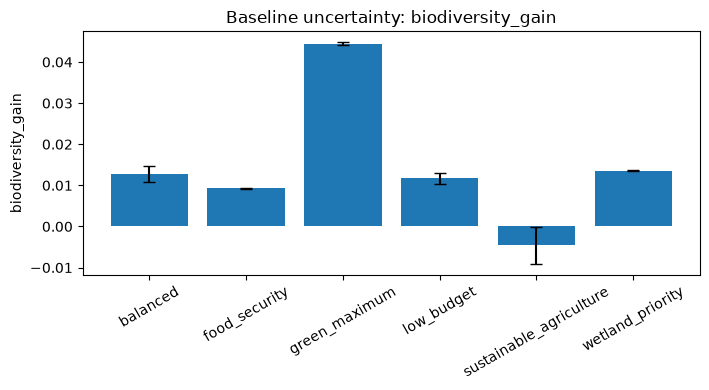

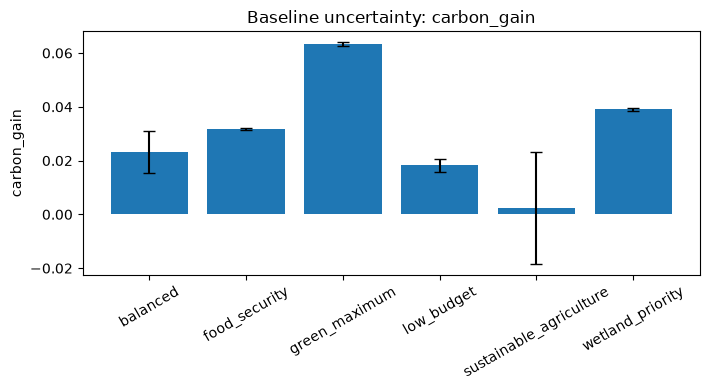

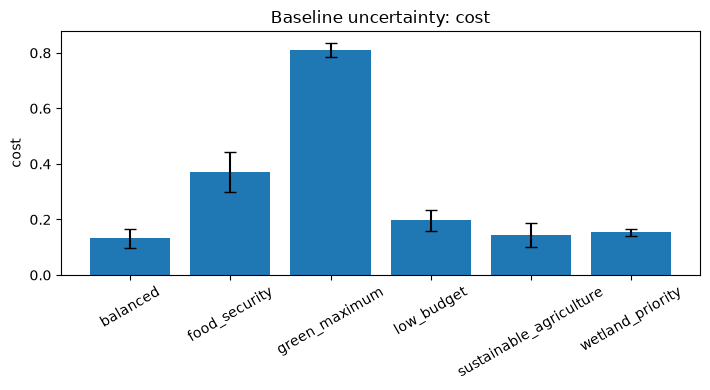

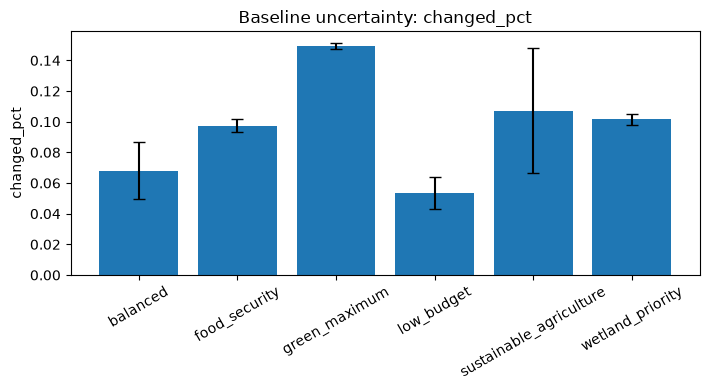

In [5]:
metrics = pd.concat([pd.read_parquet(path) for path in statuses["metrics_path"]], ignore_index=True)
baseline_summary = summarize_baseline(metrics, OUTCOMES)
display(baseline_summary)
for outcome in OUTCOMES:
    figure, _ = plot_baseline_uncertainty(baseline_summary, outcome)
    display(figure)
    plt.close(figure)
